In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
torch.manual_seed(42)

In [12]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [13]:
df=pd.read_csv("sample_data/fmnist_small.csv")

In [14]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0.0,7.0,0.0,50.0,205.0,196.0,213.0,165.0,0.0,0.0
1,7,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,1,0,0,0,...,142.0,142.0,142.0,21.0,0.0,3.0,0.0,0.0,0.0,0.0
3,8,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,8,0,0,0,0,0,0,0,0,0,...,213.0,203.0,174.0,151.0,188.0,10.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1877,1,0,0,0,0,0,0,0,0,0,...,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1878,7,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1879,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1880,4,0,0,0,0,0,0,0,0,0,...,23.0,6.0,0.0,0.0,3.0,2.0,2.0,0.0,0.0,0.0


# Basic graph

In [15]:
fruits=["apple", "banana", "orange"]

for index,fruits in enumerate(fruits):
    print(f"Index: {index}, Fruit: {fruits}")


Index: 0, Fruit: apple
Index: 1, Fruit: banana
Index: 2, Fruit: orange


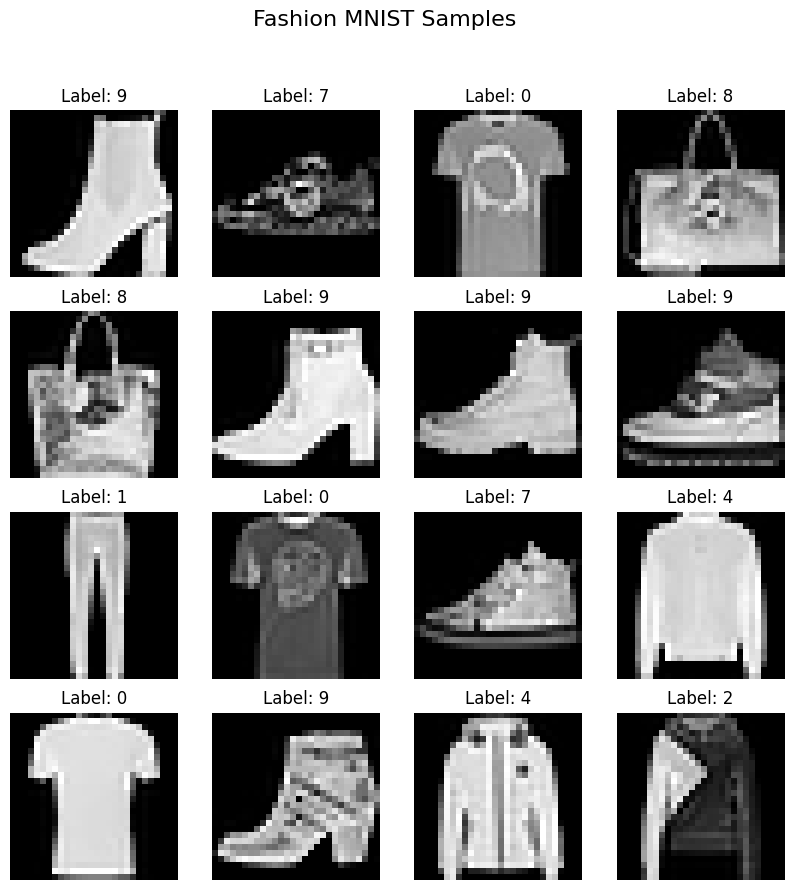

In [16]:
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("Fashion MNIST Samples",fontsize=16)

for i,ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img,cmap="gray")
    ax.axis("off")

    ax.set_title(f"Label: {df.iloc[i,0]}",fontsize=12)

In [17]:
len(df.columns)

785

In [18]:
df["label"].unique()

array([9, 7, 0, 8, 1, 4, 2, 6, 5, 3])

# Architecture
![WhatsApp Image 2026-10-02 at 7.14.52 PM.jpeg](<attachment:WhatsApp Image 2026-10-02 at 7.14.52 PM.jpeg>)

In [19]:
#train test split
x=df.iloc[:,1:].values
y=df.iloc[:,0].values


In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
#scaling the features
x_train=x_train/255.0
x_test=x_test/255.0

Workflow
![WhatsApp Image 2026-10-02 at 7.27.21 PM.jpeg](<attachment:WhatsApp Image 2026-10-02 at 7.27.21 PM.jpeg>)

# CustomDataset

In [22]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features=torch.tensor(features,dtype=torch.float32)
        self.labels=torch.tensor(labels,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self,idx):
        return self.features[idx],self.labels[idx]

In [23]:
train_dataset=CustomDataset(x_train,y_train)
test_dataset=CustomDataset(x_test,y_test)

# loaders

In [24]:
#loaders
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=64,shuffle=False,pin_memory=True)

define nn class

![WhatsApp Image 2026-10-02 at 7.14.52 PM.jpeg](<attachment:WhatsApp Image 2026-10-02 at 7.14.52 PM.jpeg>)

In [25]:
class MyNN(nn.Module):
    def __init__(self,num_features,num_classes):
        super(MyNN,self).__init__()

        self.model=nn.Sequential(
            nn.Linear(num_features,128), #linear layer (input features, output features)
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,num_classes)
        )


    def forward(self,x):
        x=self.model(x)
        return x

# instatiate Model

In [26]:
epochs=100
learning_rate=0.001


In [27]:
model=MyNN(x_train.shape[1],num_classes=10)
model.to(device)

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [28]:
#loss function
criterion=nn.CrossEntropyLoss()


In [29]:
#optimizer=optim.Adam(model.parameters(),lr=learning_rate)

optimizer=optim.SGD(model.parameters(),lr=learning_rate)

In [30]:
#train loop
for epoch in range(epochs):
    total_epoch_loss=0.0
    for batch_features,batch_labels in train_loader:

        #move data to gpu
        batch_features=batch_features.to(device)
        batch_labels=batch_labels.to(device)

        #forward pass
        outputs=model(batch_features)
        #calculate  loss
        loss=criterion(outputs,batch_labels)

        #backward pass
        loss.backward()
        optimizer.zero_grad()

        #weight update
        optimizer.step()
        total_epoch_loss += loss.item()
        print(loss.item())
avg_loss=total_epoch_loss/len(train_loader)
print(avg_loss)


2.289170265197754
2.3244032859802246
2.3127288818359375
2.3250858783721924
2.30667781829834
2.304243564605713
2.3176543712615967
2.324960708618164
2.309535503387451
2.304222345352173
2.303065299987793
nan
2.325812578201294
2.318398952484131
2.303675651550293
2.2996230125427246
2.320621967315674
2.3087453842163086
2.29886531829834
2.3214404582977295
2.313255548477173
2.302058219909668
2.3226194381713867
2.3309547901153564
2.3206605911254883
2.319826126098633
nan
2.31272554397583
2.323589563369751
2.3282289505004883
2.3159737586975098
2.313323736190796
2.3031516075134277
2.3246374130249023
2.303973913192749
2.2882449626922607
2.2899110317230225
2.3039474487304688
2.3169589042663574
2.318192481994629
2.32845401763916
2.327282667160034
2.295504570007324
2.3000335693359375
2.3206634521484375
2.316211462020874
2.2990593910217285
2.298062324523926
2.293635845184326
2.3031539916992188
2.311100482940674
2.322577476501465
2.3112754821777344
2.3036210536956787
2.3161604404449463
nan
2.30532741546

In [31]:
from torch.utils.data import DataLoader
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)
model.eval()

total=0
currect=0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        currect += (predicted == batch_labels).sum().item()

print('Accuracy: {} %'.format(100 * currect / total))

Accuracy: 6.36604774535809 %


In [32]:
print("total number of test samples: {}".format(total))
print("number of correctly classified samples: {}".format(currect))

total number of test samples: 377
number of correctly classified samples: 24
